In [1]:
import os
from pathlib import Path
os.chdir(Path("C:/Users/apaks/projects/blog-writing-agent"))

In [2]:
import operator
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated
from pydantic import BaseModel, Field
import re

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from src.blog_writing_agent.utils import load_prompt

C:\Users\apaks\AppData\Local\Temp\ipykernel_2712\1929223283.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


--- Schemas ---

In [3]:

class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ..., 
        description="One sentence describing what the reader should be able to understand/do after this section."
    )
    bullets: List[str] = Field(
        ...,
        min_length= 3,
        max_length=6,
        description="3-6 concrete, non-overlapping subpoints to cover in this section."
    )

    target_words: int = Field(
        ...,
        description= "Target word count for this section. (120-550)"
    )

    tags: List[str] = Field(
        default_factory= list
    )

    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

In [4]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparision", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory= list)
    tasks: List[Task]

In [5]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None    # keep if tavily provides else ignore
    snippet: Optional[str] = None
    source : Optional[str] = None


In [6]:
class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal['closed_book', 'hybrid', 'open_book']
    queries : List[str] = Field(default_factory = list)

In [7]:
class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory= list)

--- State ---

In [8]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research : bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # worker
    sections: Annotated[List[tuple[int, str]], operator.add]
    final: str

--- llm ---

In [9]:
llm = ChatOpenAI(model = 'gpt-4.1-mini')

Router

In [10]:
router_prompt = load_prompt("router_decision_prompt")

In [11]:
def router_node(state: State) -> State:
    topic = state['topic']
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content = router_prompt),
            HumanMessage(content = f"Topic: {topic}")
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries
    }

In [12]:
# conditional function to route to reach or orchestrator node
def route_next(state: State):
    return "research" if state['needs_research'] else "orchestrator"

Research

In [13]:
# tavily search
def _tavily_search(query: str, max_results: int) -> List[dict]:
    tool = TavilySearchResults(max_results= max_results)
    results = tool.invoke({"query": query})

    normalised: List[dict] = []

    for r in results or []:
        normalised.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source")
            }
        )
    return normalised

def research_node(state: State) -> State:
    # take first 10 queries from the state
    queries = (state.get("queries", []) or [])
    max_results = 6
    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(query=q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)

    pack = extractor.invoke(
        [
            SystemMessage(content = load_prompt("research_prompt")),
            HumanMessage(content = f"Raw Results : \n{raw_results}")
        ]
    )

    # deduplicate by url
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {
        "evidence": list(dedup.values())
    }

In [14]:
def orchestrator(state: State):
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content= load_prompt("orchestrator_prompt")),
            HumanMessage(content= (
                    f'Topic: {state['topic']}\n'
                    f"Mode: {state['mode']}\n\n"
                    f"Evidence (ONLY) use for fresh claims; may be empty: \n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            )
        ]
    )

    return {"plan": plan}

In [15]:
# fanout - this is required so that the output from orchestrator (plan) is sent to multiple worker to perform task parallely 
def fanout(state: State):
    
    return [Send(
        "worker",
        {
            "task": task.model_dump(),
            "topic": state['topic'],
            "mode": state['mode'],
            "plan": state['plan'].model_dump(),
            "evidence": [e.model_dump() for e in state.get("evidence", [])]
        } 
    )for task in state['plan'].tasks]

In [16]:
def worker_node(payload: dict) -> dict:
    
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=load_prompt("worker_system_prompt")),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

-- reducer --

In [21]:
def reducer(state: State):
    """concatenates all the title and all the sections"""
    title = state["plan"].blog_title
    ordered_sections = [markdown for _, markdown in sorted(state["sections"], key=lambda section: section[0])]
    body = "\n\n".join(ordered_sections).strip()

    final_md = f"# {title}\n\n{body}\n"

    # save the file 
    output_dir = Path("final_blogs")
    output_dir.mkdir(parents=True, exist_ok=True)
    title = re.sub(r'[<>:"/\\|?*]', "", title)
    file_name = title.lower().replace(" ", "_") + ".md"
    output_path = output_dir / file_name
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

-- Graph --

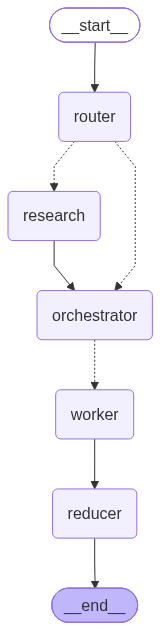

In [22]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [23]:
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [24]:
run(topic="State of Multimodal LLMs in 2026")

{'topic': 'State of Multimodal LLMs in 2026',
 'mode': 'open_book',
 'needs_research': True,
 'queries': ['State of multimodal large language models in 2026',
  'Latest advancements in multimodal LLMs as of 2026',
  'Top multimodal LLM architectures released by 2026',
  'Applications of multimodal large language models in 2026',
  'Comparison of multimodal LLMs in 2026',
  'Challenges facing multimodal LLMs in 2026',
  'Market leaders in multimodal LLM technology in 2026',
  'Recent breakthroughs in image and text fusion in LLMs (2026)'],
 'evidence': [EvidenceItem(title='Beyond Text: The Rise of Large Multimodal Models', url='https://medium.com/@adityaj5400/beyond-text-the-rise-of-large-multimodal-models-a-2026-deep-dive-0843292fa048', published_at=None, snippet='Large Multimodal Models represent a qualitative shift in AI capabilities, reshaping medicine, robotics, software development, and document workflows. In 2026, architectures are proven and open-source ecosystems competitive.',